<a href="https://colab.research.google.com/github/kyeongseiT/selfstudy-mldl/blob/main/2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02-2 데이터 전처리

## 넘파이로 데이터 준비하기

In [1]:
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [2]:
import numpy as np

column_stack()  
전달받은 리스트를 일렬로 세운 다음 차례대로 나란히 연결

[1,2,3]과 [4,5,6] 두 리스트를 일렬로 세운 다음 나란히 붙임
-> (3,2) 크기의 배열 3행 2열

In [3]:
np.column_stack(([1,2,3], [4,5,6]))

array([[1, 4],
       [2, 5],
       [3, 6]])

In [4]:
fish_data = np.column_stack((fish_length, fish_weight))

In [5]:
print(fish_data[:5])

[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]


np.ones() : 원하는 개수의 1을 채운 배열 만드는 함수  
np.zeros() : 원하는 개수의 1을 채운 배열 만드는 함수  

1이 35개인 배열  
0이 14개인 배열

---

np.column_stack() vs np.concatenate()  
np.column_stack → 열로 나란히 세움 (2차원)   (배열들을 세로로 나란히 쌓는거라 길이가 같아야됨)

np.concatenate → 일렬로 이어붙임 (1차원 유지)  

       [ 1 | 1 | 1 ]              [ 0 | 0 | 0 ]
              │                          │
              │                          │
    np.column_stack( )           np.concatenate( )
              │                          │
              ▼                          ▼
         ┌───┬───┐
         │ 1 │ 0 │
         ├───┼───┤            [ 1 | 1 | 1 | 0 | 0 | 0 ]
         │ 1 │ 0 │
         ├───┼───┤
         │ 1 │ 0 │
         └───┴───┘

In [6]:
print(np.ones(5))

[1. 1. 1. 1. 1.]


In [7]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))
print(fish_target)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


## 사이킷런으로 훈련 세트와 테스트 세트 나누기

train_test_split()
- 전달되는 리스트나 배열을 비율에 맞게 훈련 세트와 테스트 세트로 나누어줌
- 나누고 싶은 리스트나 배열을 원하는 만큰 전달하면됨
- 기본적으로 25%를 테스트 세트로 떼어냄

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42)

In [10]:
# 훈련 데이터와 테스트 데이터를 각각 36개 13개로 나눔

print(train_input.shape, test_input.shape)

print(train_target.shape, test_target.shape)

(36, 2) (13, 2)
(36,) (13,)


In [11]:
print(test_target)

[1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


13개 테스트 세트 중, 도미(1) : 10개 , 빙어(0) : 3개  
원래 : 도미 : 빙어 = 25 : 14 = **2.5 : 1**  
테스트 세트의 비율 = **3.3 : 1**  

- 샘플링편향이 조금 나타남  
무작위로 데이터를 나누었을 때 샘플이 골고루 섞이지 않을 수 있음.  
특히 일부 클래스의 갯수가 적을 때 이런일 생길 수 있음.

---

이때 train_test_split() 함수를 통하여 문제 해결 가능  
- stratify 매개변수에 타깃 데이터를 전달하면 비율에 맞게 데이터 나눠짐.
- 훈련 데이터가 작거나 특정 클래스의 샘플 개수가 적을 때 유용함.

원래 : 도미 : 빙어 = 25 : 14 = **2.5 : 1**  
테스트 세트의 비율 = **2.25 : 1**

In [12]:
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, stratify=fish_target, random_state=42)

print(test_target)

[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


## 수상한 도미 한 마리

In [13]:
# k-최근접 이웃 훈련

from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)


1.0

In [14]:
print(kn.predict([[25, 150]]))

[0.]


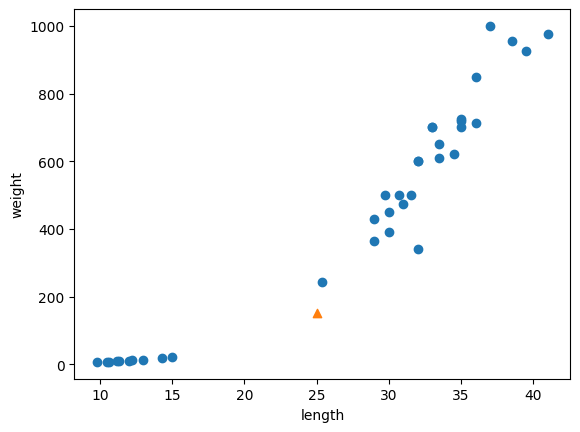

In [15]:
import matplotlib.pyplot as plt

plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')  # marker - 모양을 지정
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

분명 오른쪽 위(도미)데이터에 가까운데, 왜 왼쪽아래(빙어)데이터에 가깝다고 판단을 했을지?  

kneighbors() : 주어진 샘플에서 가장 가까운 이웃을 찾아 주는 메소드  
- 이웃까지의 거리와 이웃 샘플의 인덱스를 반환.
- 기본값은 5

In [16]:
distances, indexes = kn.kneighbors([[25, 150]])

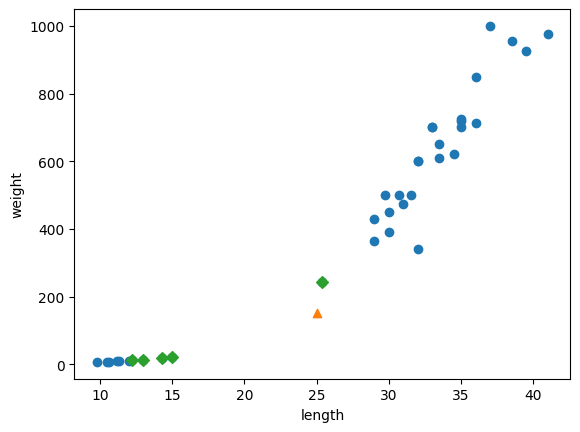

In [17]:
# indexes 배열을 사용해 훈련 데이터 중에서 이웃 샘플 따로 구분 출력

plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D') # 마커 d=마름모표시
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [19]:
# 빙어(0)이 많다..
print(train_input[indexes])
print(train_target[indexes])


[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 14.3  19.7]
  [ 13.   12.2]
  [ 12.2  12.2]]]
[[1. 0. 0. 0. 0.]]


kneighbors() 메소드에서 반환한 distances 배열을 출력함.
이 배열 = 이웃 샘플까지의 거리를 확인할 수 있음

In [20]:
print(distances)

[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]]


## 기준을 맞춰라

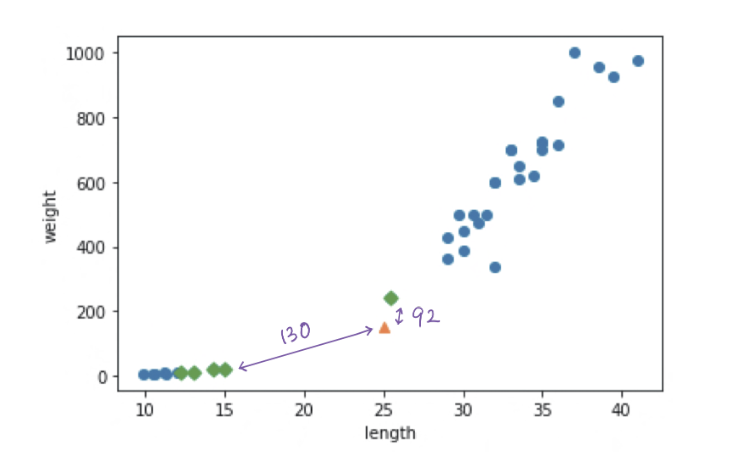

마름모 <-130-> 삼각형 <-92-> 마름모

위 표에 있는걸 보다보면, 92와 130 거리에 대한 비율이 이상해보임.  
그이유는,  
- x축은 범위가 좁음 (10 ~ 40)  
- y축은 범위가 넓음 (0 ~ 1000)

그러기 때문에, y축으로 조금만 멀어져도 거리가 아주 큰값으로 계산됨..

------
x축 범위를 동일하게 0~100으로 맞춤


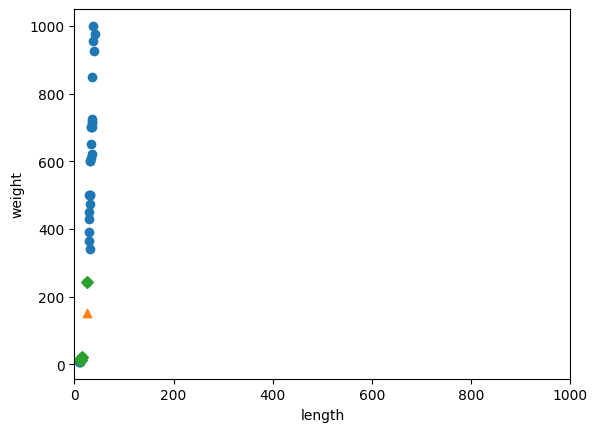

In [21]:
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(25, 150, marker='^')
plt.scatter(train_input[indexes,0], train_input[indexes,1], marker='D')
plt.xlim((0, 1000))
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

위 표를 보니, 거의 일직선으로 나타내짐.  
이런 데이터에선 x축은 k-near에 크게 영향을 주지않을듯함. 오직 y만 고려대상으로...

두 특성(길이와 무게)의 값이 놓인 범위가 다름 = 스케일(scale)이 다르다.

---------

**데이터 전처리 (data preprocessing)**
- 데이터를 표현 하는 기준이 다르면 알고리즘이 올바르게 예측할 수 없음.
- 거리 기반 알고리즘일때 특히 (k-최근접이웃 포함)
- 이런 알고리즘은 샘플 간의 거리에 영향을 많이 받으므로 제대로 사용하려면 특성값을 일정한 기준으로 맞춰야하는 작업을 데이터전처리라고함.

**표준점수(standard score)(=z점수)**
- 가장 널리 사용하는 전처리 방법 중 하나
- 각 특성값이 평균에서 표준편차의 몇 배만큼 떨여져 있는지를 나타냄.
- 이를 통해 실제 특성값의 크기와 상관없이 동일한 조건으로 비교 가능.

----------

계산법 = 평균을 빼고 표준편차를 나눔  
np.mean() = 평균 계산  
np.sid() = 표준편차 계산  

axis = 0 > 행을 따라 각 열의 통계 값을 계산.



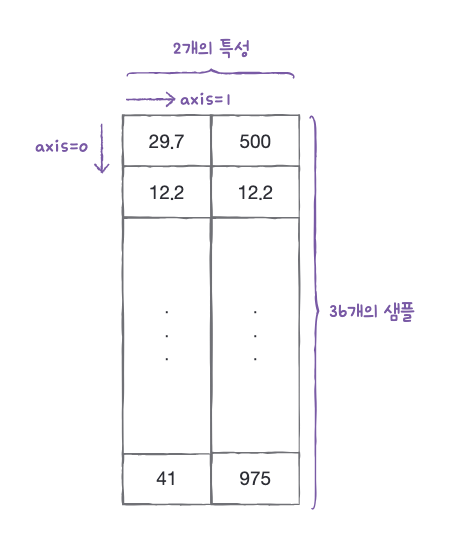

In [22]:
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)

In [23]:
# 각 특성마다 평균, 표준편차
print(mean, std)

[ 27.29722222 454.09722222] [  9.98244253 323.29893931]


In [24]:
#원본 데이터에서 평균을 빼고 표준편차로 나누어 표준점수로 변환
# 넘파이 브로드캐스팅 기능
train_scaled = (train_input - mean) / std

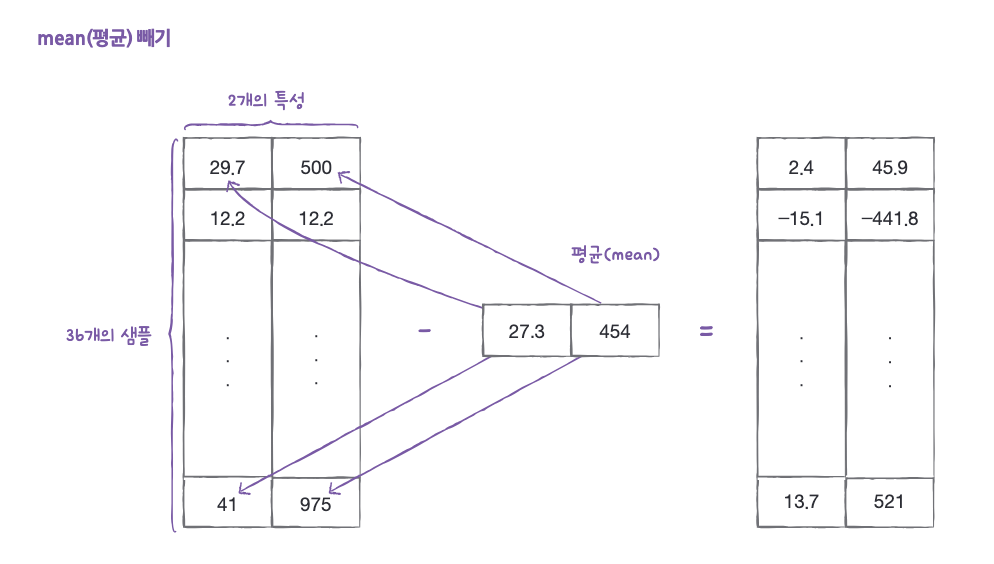

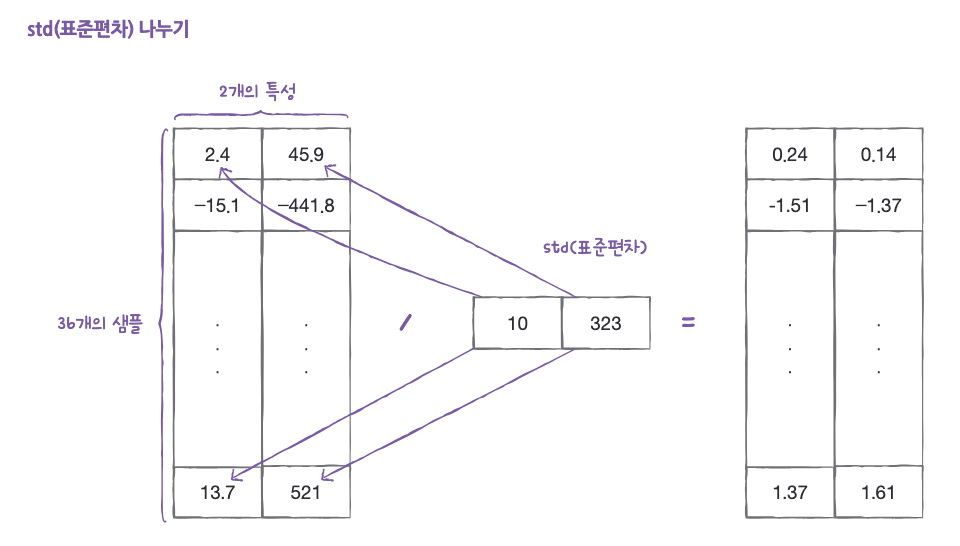

## 전처리 데이터로 모델 훈련하기

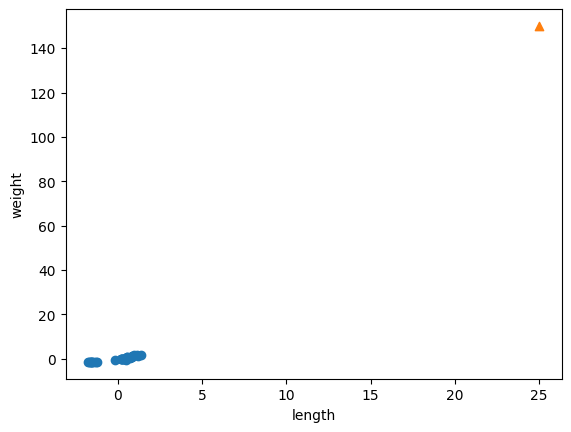

In [25]:
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(25, 150, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

훈련 세트 - mean(평균) / std(표준편차) 했기때문에 값 범위 달라짐...  
샘플 [25,150]을 동일한 비율로 하지않았기 때문..

In [26]:
new = ([25, 150] - mean) / std

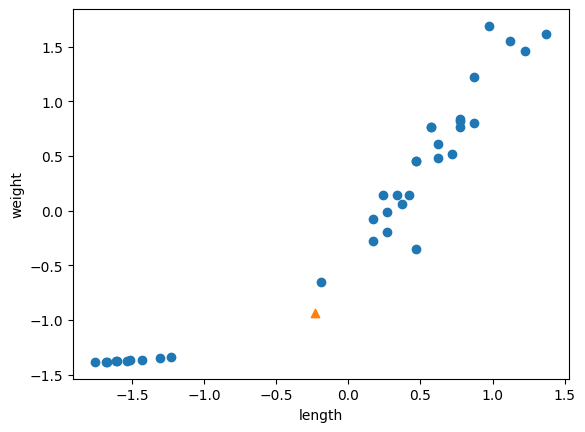

In [27]:
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

x축과 y축의 범위가 -1.5 ~ 1.5 사이로 바뀜  


In [28]:
kn.fit(train_scaled, train_target)

KNeighborsClassifier()

In [29]:
test_scaled = (test_input - mean) / std

In [30]:
kn.score(test_scaled, test_target)

1.0

In [31]:
print(kn.predict([new]))

[1.]


In [32]:
distances, indexes = kn.kneighbors([new])

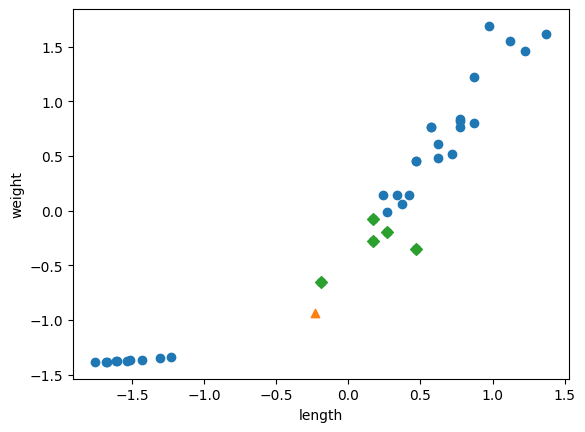

In [33]:
plt.scatter(train_scaled[:,0], train_scaled[:,1])
plt.scatter(new[0], new[1], marker='^')
plt.scatter(train_scaled[indexes,0], train_scaled[indexes,1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()